# A4: Flood Experiment Results

Analyses the 3 flood scenarios from `model_run.py`:
- **Scenario 0**: Baseline — no flood
- **Scenario 1**: Small flood at tick 1440 (intensity ×0.5)
- **Scenario 2**: High intensity flood at tick 1440 (intensity ×1.0, full spatial risk)

**Run order**: `model_run.py` → `criticality_vulnerability.ipynb` → this notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_EXP = '../data/experiment/'
DATA_PROC = '../data/data_processed/'
FLOOD_TICK = 1440
SCENARIOS = {0: 'Baseline (no flood)', 1: 'Small flood', 2: 'High intensity flood'}
COLOURS   = {0: '#888888', 1: '#F5A623', 2: '#D0021B'}

# Load all CSVs
dfs_ts    = {s: pd.read_csv(DATA_EXP + f'scenario{s}_timeseries.csv') for s in SCENARIOS}
dfs_infra = {s: pd.read_csv(DATA_EXP + f'scenario{s}_infra.csv')      for s in SCENARIOS}
dfs_sum   = {s: pd.read_csv(DATA_EXP + f'scenario{s}.csv')            for s in SCENARIOS}

print('Loaded. Timeseries rows:', {s: len(v) for s, v in dfs_ts.items()})

Loaded. Timeseries rows: {0: 492245, 1: 472930, 2: 454332}


## Plot 1: Travel time time-series
Rolling mean travel time per 200-tick window, averaged over 5 seeds. The vertical dashed line marks the flood event.

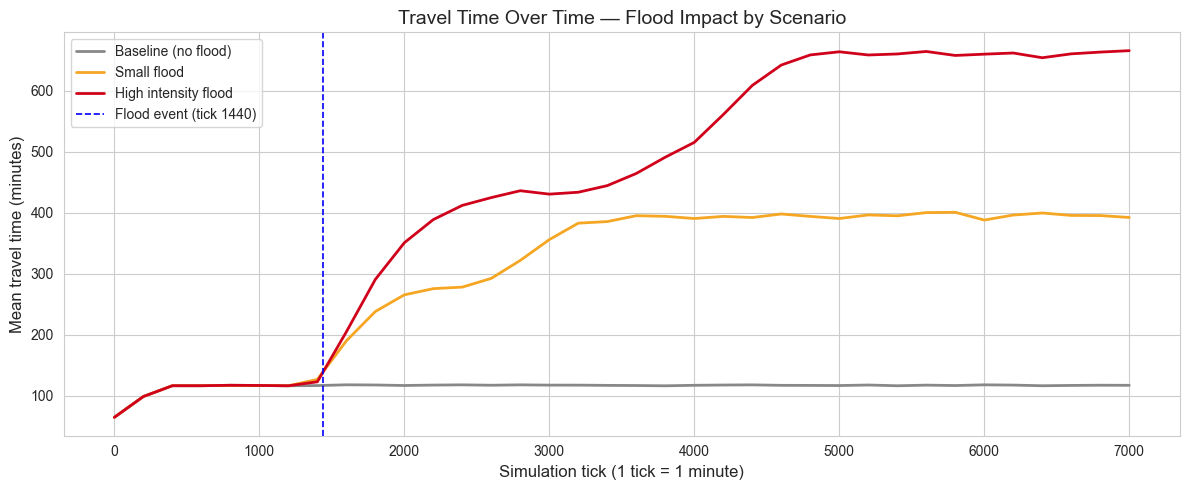

In [2]:
WINDOW = 200  # ticks per rolling bin

fig, ax = plt.subplots(figsize=(12, 5))

for s, label in SCENARIOS.items():
    df = dfs_ts[s].copy()
    # Bin ticks into windows and compute mean per bin, then average over seeds
    df['bin'] = (df['tick'] // WINDOW) * WINDOW
    mean_per_seed = df.groupby(['Seed', 'bin'])['travel_time'].mean().reset_index()
    mean_all = mean_per_seed.groupby('bin')['travel_time'].mean()
    ax.plot(mean_all.index, mean_all.values, label=label, color=COLOURS[s], linewidth=2)

ax.axvline(FLOOD_TICK, color='blue', linestyle='--', linewidth=1.2, label='Flood event (tick 1440)')
ax.set_xlabel('Simulation tick (1 tick = 1 minute)', fontsize=12)
ax.set_ylabel('Mean travel time (minutes)', fontsize=12)
ax.set_title('Travel Time Over Time — Flood Impact by Scenario', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC + 'flood_timeseries.png', dpi=150)
plt.show()

## Plot 2: Pre vs post-flood travel time (box plot)
Statistical comparison of travel times before and after the flood, per scenario.

/var/folders/04/yj5x8lbx49sc1jbf3gyzwr3h0000gn/T/ipykernel_42978/1396356612.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=phases,
/var/folders/04/yj5x8lbx49sc1jbf3gyzwr3h0000gn/T/ipykernel_42978/1396356612.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=phases,
/var/folders/04/yj5x8lbx49sc1jbf3gyzwr3h0000gn/T/ipykernel_42978/1396356612.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=phases,


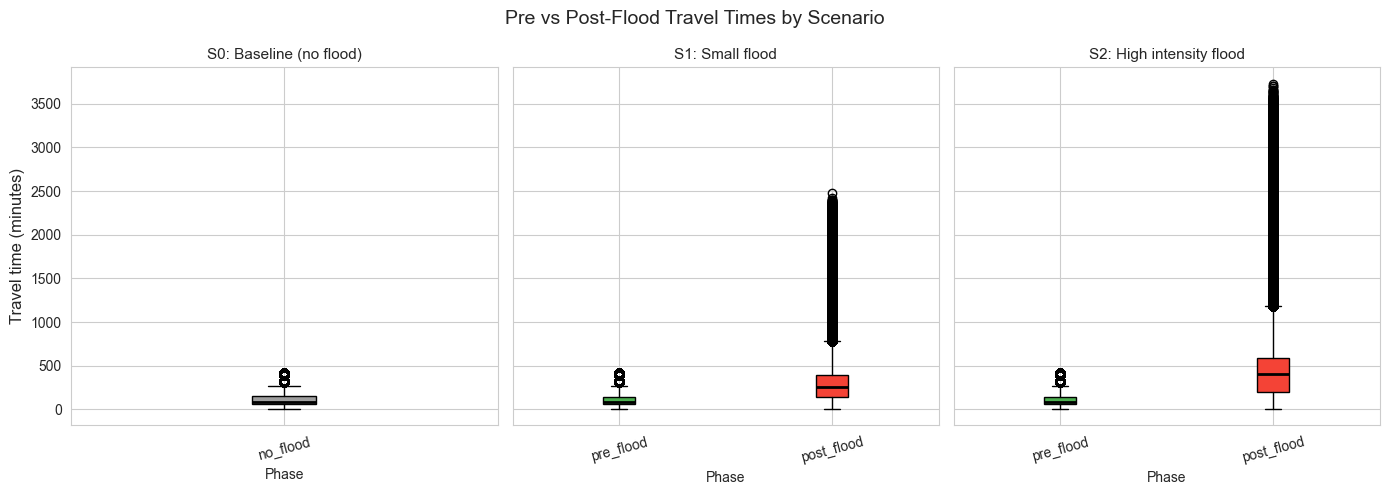

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, (s, label) in zip(axes, SCENARIOS.items()):
    df = dfs_ts[s]
    phases = df['phase'].unique().tolist()
    data   = [df[df['phase'] == p]['travel_time'].values for p in phases]
    bp = ax.boxplot(data, patch_artist=True, labels=phases,
                    medianprops={'color': 'black', 'linewidth': 2})
    phase_colours = {'pre_flood': '#4CAF50', 'post_flood': '#F44336', 'no_flood': '#9E9E9E'}
    for patch, phase in zip(bp['boxes'], phases):
        patch.set_facecolor(phase_colours.get(phase, '#BBBBBB'))
    ax.set_title(f'S{s}: {label}', fontsize=11)
    ax.set_xlabel('Phase')
    ax.tick_params(axis='x', labelrotation=15)

axes[0].set_ylabel('Travel time (minutes)', fontsize=12)
fig.suptitle('Pre vs Post-Flood Travel Times by Scenario', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_PROC + 'flood_boxplot.png', dpi=150)
plt.show()

## Plot 3: Bridges broken by road × condition (Scenario 2)
Shows spatial differentiation: N1 (Jamuna floodplain, risk=1.0) vs N2 (northeast hills, risk=0.4).

/var/folders/04/yj5x8lbx49sc1jbf3gyzwr3h0000gn/T/ipykernel_42978/3024735471.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bridges['broke_during_flood'] = bridges['broke_during_flood'].fillna(False).astype(bool)


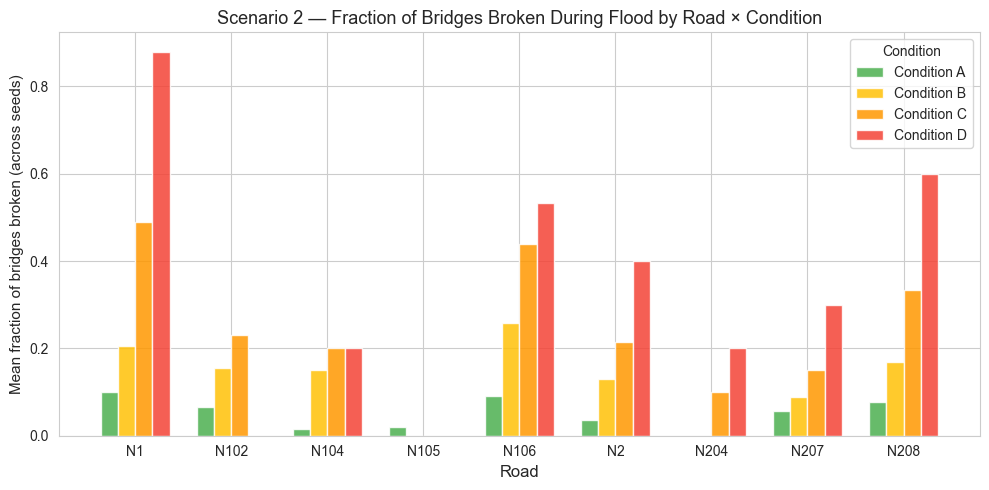

In [4]:
df_infra2 = dfs_infra[2].copy()
# Only bridges; aggregate over seeds (count how many times broke_during_flood==True)
bridges = df_infra2[df_infra2['agent_type'] == 'Bridge'].copy()
bridges['broke_during_flood'] = bridges['broke_during_flood'].fillna(False).astype(bool)

# Mean broke rate per road × condition across seeds
broke = bridges.groupby(['road', 'condition'])['broke_during_flood'].mean().unstack(fill_value=0)

cond_colours = {'A': '#4CAF50', 'B': '#FFC107', 'C': '#FF9800', 'D': '#F44336'}
conditions = [c for c in ['A', 'B', 'C', 'D'] if c in broke.columns]

x = np.arange(len(broke.index))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, cond in enumerate(conditions):
    ax.bar(x + i * width, broke[cond], width, label=f'Condition {cond}',
           color=cond_colours[cond], alpha=0.85)

ax.set_xticks(x + width * (len(conditions) - 1) / 2)
ax.set_xticklabels(broke.index)
ax.set_xlabel('Road', fontsize=12)
ax.set_ylabel('Mean fraction of bridges broken (across seeds)', fontsize=11)
ax.set_title('Scenario 2 — Fraction of Bridges Broken During Flood by Road × Condition', fontsize=13)
ax.legend(title='Condition')
plt.tight_layout()
plt.savefig(DATA_PROC + 'flood_broken_by_road.png', dpi=150)
plt.show()

## Plot 4: Summary table — avg travel time pre vs post flood

In [5]:
rows = []
for s, label in SCENARIOS.items():
    df = dfs_ts[s]
    pre  = df[df['phase'] == 'pre_flood']['travel_time'].mean()
    post = df[df['phase'] == 'post_flood']['travel_time'].mean()
    base = df[df['phase'] == 'no_flood']['travel_time'].mean()
    if pd.isna(pre):   pre  = base
    if pd.isna(post):  post = base
    pct = ((post - pre) / pre * 100) if pre and pre > 0 else float('nan')
    rows.append({
        'Scenario': f'S{s}: {label}',
        'Avg travel time pre-flood (min)':  round(pre,  1),
        'Avg travel time post-flood (min)': round(post, 1),
        'Increase (%)': round(pct, 1) if not pd.isna(pct) else '-',
    })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))
df_summary

                Scenario  Avg travel time pre-flood (min)  Avg travel time post-flood (min)  Increase (%)
 S0: Baseline (no flood)                            116.3                             116.3           0.0
         S1: Small flood                            110.7                             361.7         226.7
S2: High intensity flood                            110.7                             548.7         395.6


,Scenario,Avg travel time pre-flood (min),Avg travel time post-flood (min),Increase (%)
0,S0: Baseline (no flood),116.3,116.3,0.0
1,S1: Small flood,110.7,361.7,226.7
2,S2: High intensity flood,110.7,548.7,395.6


## Plot 5: Geographic map — broken bridges on criticality map
Grey bubbles = all bridges (size proportional to criticality). Red = broke during high-intensity flood (Scenario 2).

/var/folders/04/yj5x8lbx49sc1jbf3gyzwr3h0000gn/T/ipykernel_42978/2142736421.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_infra2_bridges['broke_during_flood'] = df_infra2_bridges['broke_during_flood'].fillna(False).astype(bool)


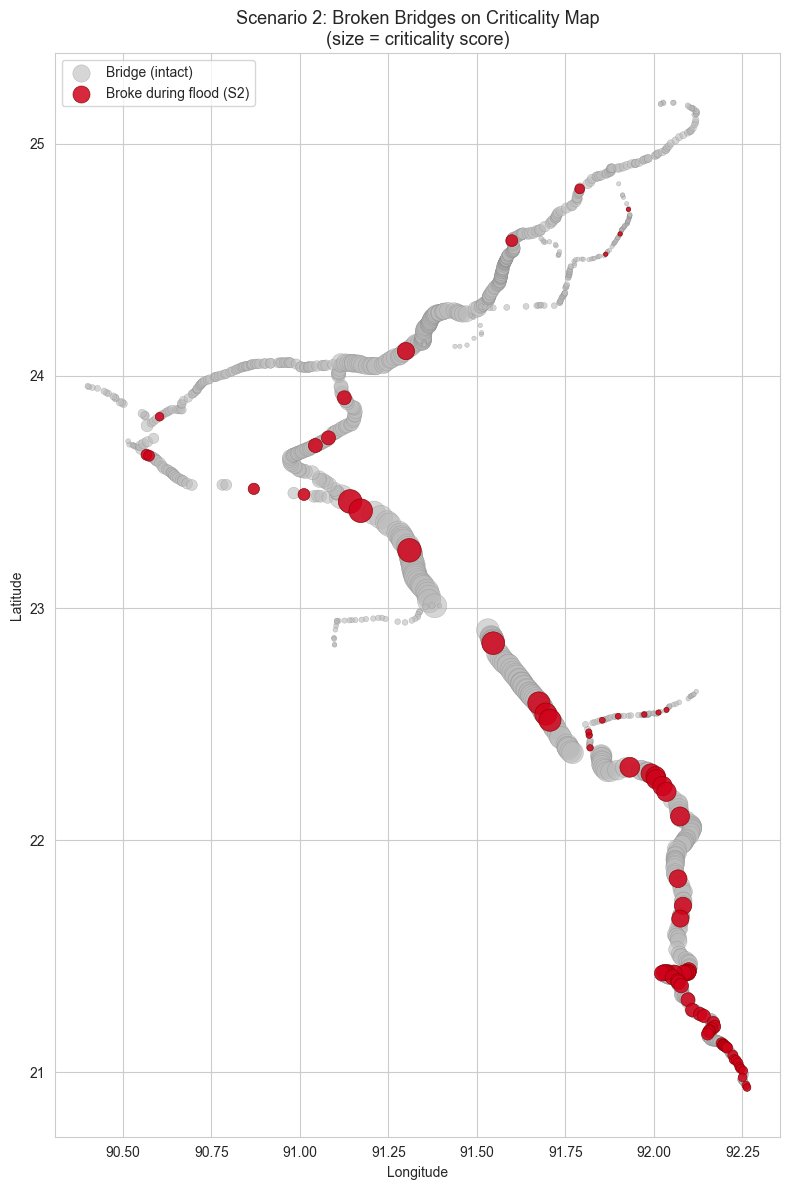

Total bridges: 1146 | Broke in ≥50% of seeds: 80


In [6]:
df_crit = pd.read_csv(DATA_PROC + 'bridge_analysis.csv')

# Aggregate scenario 2 infra: for each agent, did it break in the majority of seeds?
df_infra2_bridges = dfs_infra[2][dfs_infra[2]['agent_type'] == 'Bridge'].copy()
df_infra2_bridges['broke_during_flood'] = df_infra2_bridges['broke_during_flood'].fillna(False).astype(bool)
broke_flag = df_infra2_bridges.groupby('agent_id')['broke_during_flood'].mean()  # fraction of seeds where it broke
broke_flag = (broke_flag >= 0.5).rename('broke_majority')  # True if broke in ≥50% of seeds

df_map = df_crit.merge(broke_flag.reset_index(), left_on='agent_id', right_on='agent_id', how='left')
df_map['broke_majority'] = df_map['broke_majority'].fillna(False)

# Normalise criticality to bubble size
crit = df_map['criticality_score'].fillna(0).values
if crit.max() > 0:
    sizes = 10 + 290 * (crit - crit.min()) / (crit.max() - crit.min() + 1e-9)
else:
    sizes = np.full(len(crit), 20)

fig, ax = plt.subplots(figsize=(8, 12))

# All bridges — grey
ax.scatter(df_map['lon'], df_map['lat'], s=sizes, c='#BBBBBB',
           alpha=0.6, edgecolors='#888888', linewidths=0.3, label='Bridge (intact)')

# Broken bridges — red
mask_broke = df_map['broke_majority']
ax.scatter(df_map[mask_broke]['lon'], df_map[mask_broke]['lat'],
           s=sizes[mask_broke], c='#D0021B',
           alpha=0.85, edgecolors='darkred', linewidths=0.5, label='Broke during flood (S2)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Scenario 2: Broken Bridges on Criticality Map\n(size = criticality score)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC + 'flood_geo_broken.png', dpi=150)
plt.show()

print(f'Total bridges: {len(df_map)} | Broke in ≥50% of seeds: {mask_broke.sum()}')